# Final Project: Predicting 30-Day Readmission for Diabetic Patients

This project builds a complete **scikit-learn machine learning pipeline** for the **Diabetes 130-US hospitals (1999–2008)** dataset.

### Problem Definition

The goal of this project is to predict whether a patient will be readmitted to the hospital within a certain period after discharge. This is formulated as a **binary classification problem**, where:

- **Positive class (1):** Patient is readmitted
- **Negative class (0):** Patient is not readmitted

### Objective
We aim to build a predictive model that can identify high-risk patients in advance, which is important in healthcare settings where early intervention can reduce costs and improve patient outcomes.

### Challenges
(will show why these challenges exist in later sections)
- **Class imbalance**: The number of readmitted cases is much smaller than non-readmitted cases.
- **High-dimensional features**: The dataset includes many categorical and clinical variables.
- **Data quality issues**: Missing values and inconsistent coding may affect model performance.

### Evaluation Metrics
Given the class imbalance, we focus on:
- AUC (Area Under the ROC Curve)
- Precision / Recall
- F1-score

Accuracy alone is not sufficient for this task.

### Target definition
We convert the original `readmitted` variable into a binary target:

- `1` = `<30`
- `0` = `>30` or `NO`

### Models compared
This notebook trains and compares six models:

1. Logistic Regression  
2. K-Nearest Neighbors  
3. Decision Tree  
4. Random Forest  
5. Gradient Boosting  
6. MLP (Neural Network)


In [1]:
# If needed, uncomment and run:
# !pip install pandas numpy matplotlib scikit-learn imbalanced-learn seaborn

In [2]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    roc_auc_score, accuracy_score, precision_score, recall_score, f1_score,
    RocCurveDisplay, confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.inspection import permutation_importance

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neural_network import MLPClassifier

from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import RandomOverSampler

RANDOM_STATE = 42

## 1. Load data

- `diabetic_data.csv`
- `IDs_mapping.csv` or `IDs_mappings.csv` (optional)
- `Data Dictionary.png` (optional)

This notebook uses `diabetic_data.csv` directly.

In [3]:
# Adjust this path if needed
DATA_DIR = Path("./data")

# Main data file
data_path = DATA_DIR / "diabetic_data.csv"

if not data_path.exists():
    raise FileNotFoundError(
        "Could not find 'diabetic_data.csv'. Put the file in the same folder as this notebook, "
        "or update DATA_DIR above."
    )

df_raw = pd.read_csv(data_path)
print("Shape:", df_raw.shape)
df_raw.head()

Shape: (101766, 50)


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,2278392,8222157,Caucasian,Female,[0-10),?,6,25,1,1,...,No,No,No,No,No,No,No,No,No,NO
1,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
2,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
3,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
4,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO


## 2. Initial inspection (EDA)

In [4]:
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 50 columns):
 #   Column                    Non-Null Count   Dtype
---  ------                    --------------   -----
 0   encounter_id              101766 non-null  int64
 1   patient_nbr               101766 non-null  int64
 2   race                      101766 non-null  str  
 3   gender                    101766 non-null  str  
 4   age                       101766 non-null  str  
 5   weight                    101766 non-null  str  
 6   admission_type_id         101766 non-null  int64
 7   discharge_disposition_id  101766 non-null  int64
 8   admission_source_id       101766 non-null  int64
 9   time_in_hospital          101766 non-null  int64
 10  payer_code                101766 non-null  str  
 11  medical_specialty         101766 non-null  str  
 12  num_lab_procedures        101766 non-null  int64
 13  num_procedures            101766 non-null  int64
 14  num_medications           10176

In [5]:
df_raw.describe(include="all").T.head(20)

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
encounter_id,101766.0,NaN,NaN,NaN,165201645.622978,102640295.983457,12522.0,84961194.0,152388987.0,230270887.5,443867222.0
patient_nbr,101766.0,NaN,NaN,NaN,54330400.694947,38696359.346534,135.0,23413221.0,45505143.0,87545949.75,189502619.0
race,101766,6,Caucasian,76099,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,101766,3,Female,54708,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,101766,10,[70-80),26068,NaN,NaN,NaN,NaN,NaN,NaN,NaN
weight,101766,10,?,98569,NaN,NaN,NaN,NaN,NaN,NaN,NaN
admission_type_id,101766.0,NaN,NaN,NaN,2.024006,1.445403,1.0,1.0,1.0,3.0,8.0
discharge_disposition_id,101766.0,NaN,NaN,NaN,3.715642,5.280166,1.0,1.0,1.0,4.0,28.0
admission_source_id,101766.0,NaN,NaN,NaN,5.754437,4.064081,1.0,1.0,7.0,7.0,25.0
time_in_hospital,101766.0,NaN,NaN,NaN,4.395987,2.985108,1.0,2.0,4.0,6.0,14.0


In [6]:
# Show raw target distribution
df_raw["readmitted"].value_counts(dropna=False)

readmitted
NO     54864
>30    35545
<30    11357
Name: count, dtype: int64

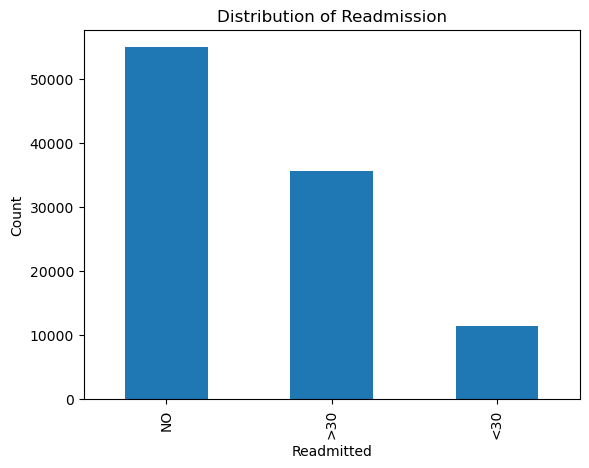

readmitted
NO     54864
>30    35545
<30    11357
Name: count, dtype: int64


In [8]:
df_raw["readmitted"].value_counts().plot(kind="bar")
plt.title("Distribution of Readmission")
plt.xlabel("Readmitted")
plt.ylabel("Count")
plt.show()

print(df_raw["readmitted"].value_counts(dropna=False))


The dataset is highly imbalanced. Only a small proportion of patients are readmitted in 30 days, which makes the prediction task more challenging.

This imbalance motivates the use of evaluation metrics such as AUC, precision, recall, and F1-score instead of accuracy.

In [11]:
num_features = df_raw.select_dtypes(include=["int64", "float64"]).columns.tolist()
cat_features = df_raw.select_dtypes(include=["object"]).columns.tolist()

print("Total number of features:", df_raw.shape[1] - 1) 
print("Categorical features:", len(cat_features))

Total number of features: 49
Categorical features: 37


The dataset contains many categorical variables, several of which have a large number of distinct levels. This increases preprocessing complexity and motivates feature engineering steps such as encoding, grouping rare categories, and variable selection.

In [15]:
missing_summary = df_raw.isna().sum().sort_values(ascending=False)
missing_pct = (df_raw.isna().mean() * 100).sort_values(ascending=False)

missing_df = pd.DataFrame(
    {"missing_count": missing_summary, "missing_pct": missing_pct}
)

print(missing_df.head(15))

                          missing_count  missing_pct
max_glu_serum                     96420    94.746772
A1Cresult                         84748    83.277322
race                                  0     0.000000
gender                                0     0.000000
age                                   0     0.000000
weight                                0     0.000000
admission_type_id                     0     0.000000
discharge_disposition_id              0     0.000000
admission_source_id                   0     0.000000
time_in_hospital                      0     0.000000
payer_code                            0     0.000000
medical_specialty                     0     0.000000
num_lab_procedures                    0     0.000000
num_procedures                        0     0.000000
num_medications                       0     0.000000


The dataset also presents data quality issues. Several variables contain missing values, and some categorical features use ambiguous or inconsistent codes. These issues may reduce model reliability if not handled carefully, and therefore motivate preprocessing steps such as missing-value treatment, category consolidation, and removal of low-information variables.

## 3. Data cleaning and target construction

In [17]:
def clean_diabetes_data(df: pd.DataFrame, missing_col_threshold: float = 0.80) -> pd.DataFrame:
    df = df.copy()

    # Convert placeholder missing values to actual NaN
    df = df.replace("?", np.nan)

    # Remove ID-like variables
    for col in ["encounter_id", "patient_nbr"]:
        if col in df.columns:
            df = df.drop(columns=col)

    # Remove rows with missing target
    df = df[df["readmitted"].notna()].copy()

    # Binary target: <30 = 1, otherwise = 0
    df["target_readmit_30d"] = (df["readmitted"] == "<30").astype(int)

    # Drop original target after creating the binary version
    df = df.drop(columns=["readmitted"])

    # Drop columns that are entirely missing
    all_missing_cols = df.columns[df.isna().all()].tolist()
    if all_missing_cols:
        print("Dropping all-missing columns:", all_missing_cols)
        df = df.drop(columns=all_missing_cols)

    # Drop columns with more than the specified missing-value threshold
    missing_rate = df.isna().mean()
    high_missing_cols = missing_rate[missing_rate > missing_col_threshold].index.tolist()
    if high_missing_cols:
        print(
            f"Dropping columns with more than {int(missing_col_threshold * 100)}% missing values:",
            high_missing_cols
        )
        df = df.drop(columns=high_missing_cols)

    return df

In [18]:
df = clean_diabetes_data(df_raw)
print("Cleaned shape:", df.shape)
df.head()
df["target_readmit_30d"].value_counts(normalize=True)

Dropping columns with more than 80% missing values: ['weight', 'max_glu_serum', 'A1Cresult']
Cleaned shape: (101766, 45)


target_readmit_30d
0    0.888401
1    0.111599
Name: proportion, dtype: float64

Here we also dropped weight, which is not shown in the previous missing value check. This is because many missing entries in weight were encoded as the placeholder "?" rather than as true NaN values, so they were not captured by the raw isna() summary. After treating "?" as missing, weight was found to be highly incomplete and was therefore removed during preprocessing.

## 4. feature engineering

This dataset contains many categorical medication columns with values like `No`, `Steady`, `Up`, `Down`.

We add a few clinically meaningful summary features:

- `num_diabetes_drugs_used`
- `num_diabetes_drugs_changed`
- `service_use_total`
- `has_prior_inpatient`
- `has_emergency_visit`
- `long_stay`

In [11]:
MEDICATION_COLS = [
    "metformin", "repaglinide", "nateglinide", "chlorpropamide", "glimepiride",
    "acetohexamide", "glipizide", "glyburide", "tolbutamide", "pioglitazone",
    "rosiglitazone", "acarbose", "miglitol", "troglitazone", "tolazamide",
    "examide", "citoglipton", "insulin", "glyburide-metformin",
    "glipizide-metformin", "glimepiride-pioglitazone", "metformin-rosiglitazone",
    "metformin-pioglitazone"
]

def add_engineered_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    meds_present = [c for c in MEDICATION_COLS if c in df.columns]
    if meds_present:
        med_frame = df[meds_present].fillna("No")
        df["num_diabetes_drugs_used"] = (med_frame != "No").sum(axis=1)
        df["num_diabetes_drugs_changed"] = med_frame.isin(["Up", "Down"]).sum(axis=1)

    if {"number_outpatient", "number_emergency", "number_inpatient"}.issubset(df.columns):
        df["service_use_total"] = (
            df["number_outpatient"].fillna(0)
            + df["number_emergency"].fillna(0)
            + df["number_inpatient"].fillna(0)
        )
        df["has_prior_inpatient"] = (df["number_inpatient"].fillna(0) > 0).astype(int)
        df["has_emergency_visit"] = (df["number_emergency"].fillna(0) > 0).astype(int)

    if "time_in_hospital" in df.columns:
        df["long_stay"] = (df["time_in_hospital"].fillna(0) >= 7).astype(int)

    return df

df = add_engineered_features(df)
df.head()

,race,gender,age,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,payer_code,medical_specialty,num_lab_procedures,...,metformin-pioglitazone,change,diabetesMed,target_readmit_30d,num_diabetes_drugs_used,num_diabetes_drugs_changed,service_use_total,has_prior_inpatient,has_emergency_visit,long_stay
0,Caucasian,Female,[0-10),6,25,1,1,NaN,Pediatrics-Endocrinology,41,...,No,No,No,0,0,0,0,0,0,0
1,Caucasian,Female,[10-20),1,1,7,3,NaN,NaN,59,...,No,Ch,Yes,0,1,1,0,0,0,0
2,AfricanAmerican,Female,[20-30),1,1,7,2,NaN,NaN,11,...,No,No,Yes,0,1,0,3,1,0,0
3,Caucasian,Male,[30-40),1,1,7,2,NaN,NaN,44,...,No,Ch,Yes,0,1,1,0,0,0,0
4,Caucasian,Male,[40-50),1,1,7,1,NaN,NaN,51,...,No,Ch,Yes,0,2,0,0,0,0,0


## 6. Train/validation split

In [15]:
X = df.drop(columns=["target_readmit_30d"])
y = df["target_readmit_30d"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape :", X_test.shape)
print("Train positive rate:", y_train.mean().round(4))
print("Test positive rate :", y_test.mean().round(4))

Train shape: (81412, 50)
Test shape : (20354, 50)
Train positive rate: 0.1116
Test positive rate : 0.1116


## 7. Build preprocessing + balancing pipeline

We use:
- median imputation for numeric columns
- most-frequent imputation + one-hot encoding for categorical columns
- `RandomOverSampler` from **imblearn**, applied **only inside the training folds / training split**

This avoids data leakage and addresses class imbalance in a pipeline-safe way.

To keep all models compatible, the encoder outputs a dense matrix.

In [16]:
numeric_features = X_train.select_dtypes(include=["number"]).columns.tolist()
categorical_features = X_train.select_dtypes(exclude=["number"]).columns.tolist()

print("Numeric features:", len(numeric_features))
print("Categorical features:", len(categorical_features))
print("Example categorical columns:", categorical_features[:10])

Numeric features: 17
Categorical features: 33
Example categorical columns: ['race', 'gender', 'age', 'payer_code', 'medical_specialty', 'diag_1', 'diag_2', 'diag_3', 'metformin', 'repaglinide']


In [17]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ],
    remainder="drop"
)

sampler = RandomOverSampler(random_state=RANDOM_STATE)

## 8. Define models

Chosen models:
1. Logistic Regression  
2. KNN  
3. Decision Tree  
4. Random Forest  
5. Gradient Boosting
6. MLP (Neural Network)

All models will use the same preprocessing + **imblearn balancing step** inside a single pipeline.

In [18]:
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=2000,
        random_state=RANDOM_STATE
    ),
    "KNN": KNeighborsClassifier(
        n_neighbors=25
    ),
    "Decision Tree": DecisionTreeClassifier(
        random_state=RANDOM_STATE
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=300,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),
    "Gradient Boosting": GradientBoostingClassifier(
        random_state=RANDOM_STATE
    ),
    "MLP (Neural Net)": MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    max_iter=200,
    random_state=RANDOM_STATE
),
}

pipelines = {
    name: ImbPipeline(steps=[
        ("preprocessor", preprocessor),
        ("sampler", sampler),
        ("model", model)
    ])
    for name, model in models.items()
}

list(pipelines.keys())

['Logistic Regression',
 'KNN',
 'Decision Tree',
 'Random Forest',
 'Gradient Boosting',
 'MLP (Neural Net)']

## 9. Cross-validation comparison

In [19]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    "auc": "roc_auc",
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1"
}

cv_rows = []

for name, pipe in pipelines.items():
    scores = cross_validate(
        pipe,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring,
        n_jobs=-1,
        return_train_score=False
    )
    cv_rows.append({
        "model": name,
        "cv_auc_mean": scores["test_auc"].mean(),
        "cv_auc_std": scores["test_auc"].std(),
        "cv_accuracy_mean": scores["test_accuracy"].mean(),
        "cv_precision_mean": scores["test_precision"].mean(),
        "cv_recall_mean": scores["test_recall"].mean(),
        "cv_f1_mean": scores["test_f1"].mean()
    })

cv_results = pd.DataFrame(cv_rows).sort_values("cv_auc_mean", ascending=False)
cv_results

,model,cv_auc_mean,cv_auc_std,cv_accuracy_mean,cv_precision_mean,cv_recall_mean,cv_f1_mean
4,Gradient Boosting,0.668752,0.006665,0.638469,0.174719,0.601363,0.270757
3,Random Forest,0.651401,0.006399,0.888370,0.501440,0.017500,0.033797
0,Logistic Regression,0.628127,0.005233,0.639328,0.161387,0.531697,0.247609
1,KNN,0.583241,0.005815,0.578011,0.138595,0.533238,0.220003
5,MLP (Neural Net),0.569497,0.009904,0.804980,0.156229,0.169383,0.162497
2,Decision Tree,0.541954,0.002505,0.792721,0.169123,0.219128,0.190894


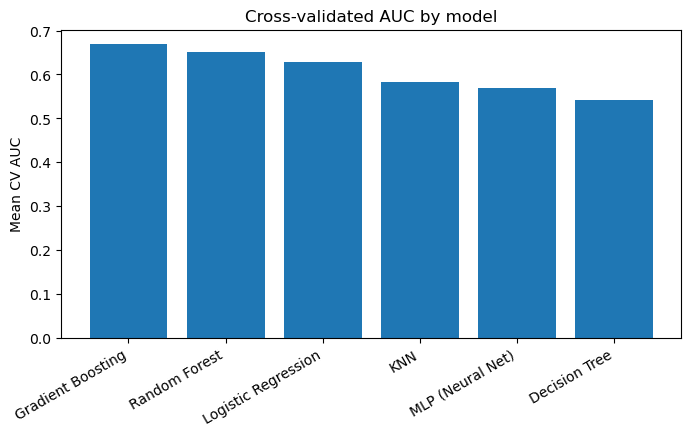

In [20]:
plt.figure(figsize=(8,4))
plt.bar(cv_results["model"], cv_results["cv_auc_mean"])
plt.xticks(rotation=30, ha="right")
plt.ylabel("Mean CV AUC")
plt.title("Cross-validated AUC by model")
plt.show()

## 10. Fit on the training split and evaluate on the holdout test split

In [21]:
holdout_rows = []
fitted_pipelines = {}

for name, pipe in pipelines.items():
    pipe.fit(X_train, y_train)
    fitted_pipelines[name] = pipe

    y_prob = pipe.predict_proba(X_test)[:, 1]
    y_pred = (y_prob >= 0.5).astype(int)

    holdout_rows.append({
        "model": name,
        "test_auc": roc_auc_score(y_test, y_prob),
        "test_accuracy": accuracy_score(y_test, y_pred),
        "test_precision": precision_score(y_test, y_pred, zero_division=0),
        "test_recall": recall_score(y_test, y_pred, zero_division=0),
        "test_f1": f1_score(y_test, y_pred, zero_division=0)
    })

holdout_results = pd.DataFrame(holdout_rows).sort_values("test_auc", ascending=False)
holdout_results

,model,test_auc,test_accuracy,test_precision,test_recall,test_f1
4,Gradient Boosting,0.678041,0.635059,0.178371,0.629679,0.277994
3,Random Forest,0.664649,0.889358,0.592233,0.026860,0.051390
0,Logistic Regression,0.643375,0.636632,0.165076,0.556143,0.254586
1,KNN,0.604021,0.586076,0.143866,0.547336,0.227843
5,MLP (Neural Net),0.581494,0.817530,0.164262,0.155438,0.159729
2,Decision Tree,0.547600,0.794782,0.176730,0.229414,0.199655


In [22]:
best_model_name = holdout_results.iloc[0]["model"]
best_pipe = fitted_pipelines[best_model_name]
print("Best baseline model on holdout AUC:", best_model_name)

Best baseline model on holdout AUC: Gradient Boosting


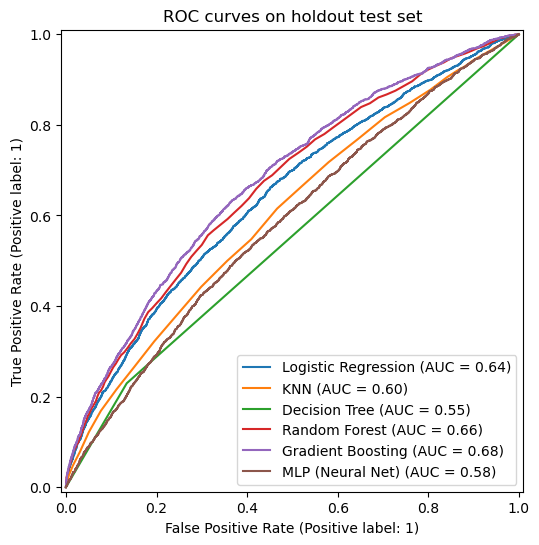

In [23]:
# ROC curves
plt.figure(figsize=(7,6))
for name, pipe in fitted_pipelines.items():
    y_prob = pipe.predict_proba(X_test)[:, 1]
    RocCurveDisplay.from_predictions(y_test, y_prob, name=name, ax=plt.gca())
plt.title("ROC curves on holdout test set")
plt.show()

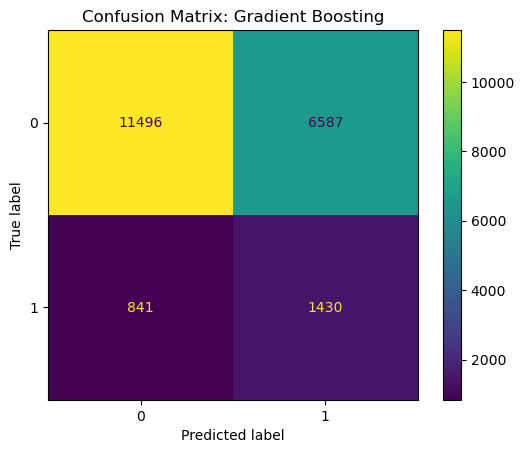

In [24]:
# Confusion matrix for the best baseline model
best_prob = best_pipe.predict_proba(X_test)[:, 1]
best_pred = (best_prob >= 0.5).astype(int)

cm = confusion_matrix(y_test, best_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title(f"Confusion Matrix: {best_model_name}")
plt.show()

## 11. Hyperparameter tuning

We tune **Random Forest** using `RandomizedSearchCV` and compare tuned vs. untuned performance.

The tuned pipeline keeps the same preprocessing + **imblearn oversampling** steps, so balancing is still performed safely inside each CV split.

In [25]:
rf_pipe = ImbPipeline(steps=[
    ("preprocessor", preprocessor),
    ("sampler", RandomOverSampler(random_state=RANDOM_STATE)),
    ("model", RandomForestClassifier(
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

param_dist = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [8, 16, None],
    "model__min_samples_split": [2, 10],
    "model__min_samples_leaf": [1, 4],
    "model__max_features": ["sqrt", None],
}

rf_search = RandomizedSearchCV(
    estimator=rf_pipe,
    param_distributions=param_dist,
    n_iter=5,
    scoring="roc_auc",
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    verbose=1,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

rf_search.fit(X_train, y_train)
print("Best params:", rf_search.best_params_)
print("Best CV AUC:", rf_search.best_score_)

Fitting 5 folds for each of 5 candidates, totalling 25 fits
Best params: {'model__n_estimators': 200, 'model__min_samples_split': 10, 'model__min_samples_leaf': 1, 'model__max_features': None, 'model__max_depth': 16}
Best CV AUC: 0.650387555367107


In [26]:
tuned_rf = rf_search.best_estimator_

# Untuned RF
untuned_rf = pipelines["Random Forest"]
untuned_rf.fit(X_train, y_train)

untuned_prob = untuned_rf.predict_proba(X_test)[:, 1]
tuned_prob = tuned_rf.predict_proba(X_test)[:, 1]

comparison_df = pd.DataFrame({
    "version": ["Untuned Random Forest", "Tuned Random Forest"],
    "test_auc": [
        roc_auc_score(y_test, untuned_prob),
        roc_auc_score(y_test, tuned_prob)
    ]
})
comparison_df

,version,test_auc
0,Untuned Random Forest,0.664649
1,Tuned Random Forest,0.672191


## 12. Feature importance / interpretation

We use the tuned Random Forest if available.  
Because the pipeline includes one-hot encoding, we extract transformed feature names first.

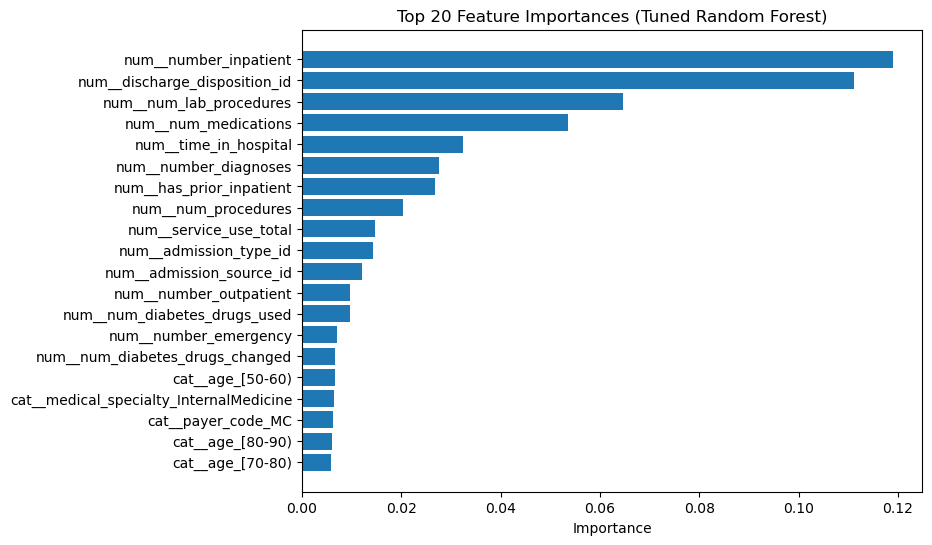

,importance
num__number_inpatient,0.118900
num__discharge_disposition_id,0.111040
num__num_lab_procedures,0.064577
num__num_medications,0.053533
num__time_in_hospital,0.032394
num__number_diagnoses,0.027572
num__has_prior_inpatient,0.026679
num__num_procedures,0.020264
num__service_use_total,0.014642
num__admission_type_id,0.014328


In [27]:
final_model = tuned_rf

# Get transformed feature names
feature_names = final_model.named_steps["preprocessor"].get_feature_names_out()

# For tree-based models with feature_importances_
rf_model = final_model.named_steps["model"]
importances = pd.Series(rf_model.feature_importances_, index=feature_names).sort_values(ascending=False)

top_k = 20
top_importances = importances.head(top_k)

plt.figure(figsize=(8,6))
plt.barh(top_importances.index[::-1], top_importances.values[::-1])
plt.title(f"Top {top_k} Feature Importances (Tuned Random Forest)")
plt.xlabel("Importance")
plt.show()

top_importances.to_frame("importance")

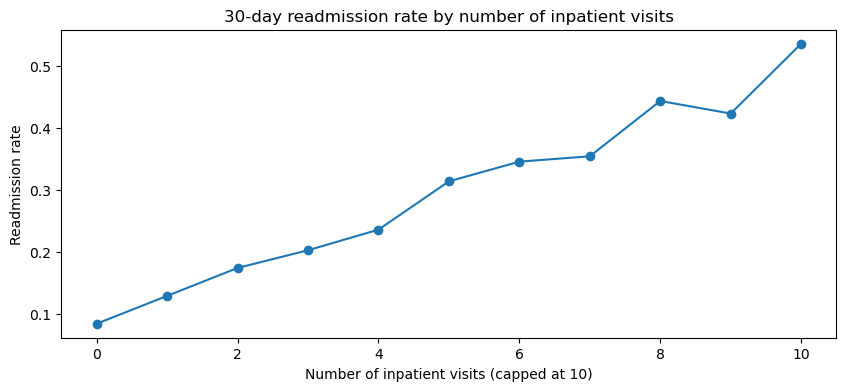

In [ ]:
# Readmission rate by number_inpatient
if "number_inpatient" in df.columns:

    df_plot = df.copy()
    df_plot["number_inpatient_capped"] = df_plot["number_inpatient"].clip(upper=10)

    inpatient_rate = (
        df_plot.groupby("number_inpatient_capped")["target_readmit_30d"]
        .mean()
        .sort_index()
    )

    plt.figure(figsize=(10, 4))
    plt.plot(inpatient_rate.index, inpatient_rate.values, marker="o")
    plt.title("30-day readmission rate by number of inpatient visits")
    plt.xlabel("Number of inpatient visits (capped at 10)")
    plt.ylabel("Readmission rate")
    plt.show()

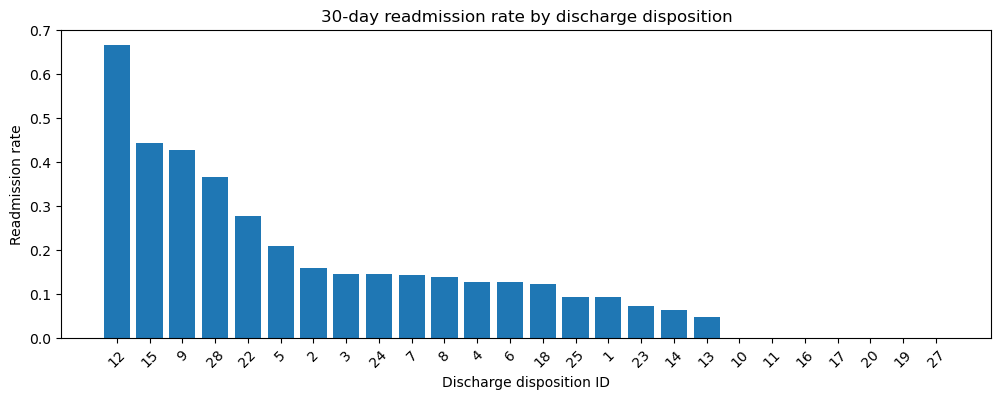

In [18]:
# Readmission rate by discharge_disposition_id
if "discharge_disposition_id" in df.columns:

    discharge_rate = (
        df.groupby("discharge_disposition_id")["target_readmit_30d"]
        .mean()
        .sort_values(ascending=False)
    )

    plt.figure(figsize=(12, 4))
    plt.bar(discharge_rate.index.astype(str), discharge_rate.values)
    plt.xticks(rotation=45)
    plt.title("30-day readmission rate by discharge disposition")
    plt.xlabel("Discharge disposition ID")
    plt.ylabel("Readmission rate")
    plt.show()

## 15. Export results tables 

In [29]:
# Save model comparison results if desired
cv_results.to_csv("cv_model_comparison.csv", index=False)
holdout_results.to_csv("holdout_model_comparison.csv", index=False)
comparison_df.to_csv("tuned_vs_untuned_random_forest.csv", index=False)

print("Saved:")
print("- cv_model_comparison.csv")
print("- holdout_model_comparison.csv")
print("- tuned_vs_untuned_random_forest.csv")

Saved:
- cv_model_comparison.csv
- holdout_model_comparison.csv
- tuned_vs_untuned_random_forest.csv


## Analysis and Interpretation of Model Results

Among the baseline models, Gradient Boosting achieved the best overall discrimination on the holdout test set, with the highest AUC. It also produced the highest recall, which is important in this project because the goal is to identify patients at risk of 30-day readmission rather than simply maximize overall accuracy. By contrast, Random Forest achieved very high accuracy but extremely low recall, suggesting that it mostly favored the majority class. This result is consistent with the class imbalance observed during EDA and shows why accuracy alone is not an appropriate metric for this task.

Hyperparameter tuning improved the Random Forest model slightly, increasing the test AUC from the untuned version. However, the tuned Random Forest still did not outperform Gradient Boosting. This suggests that while model tuning can improve performance, the larger limitation may come from the difficulty of the prediction task itself, the class imbalance, and the restricted signal available in the tabular features.

The feature importance analysis provides a clinically plausible interpretation of the model. Variables such as prior inpatient utilization, discharge disposition, number of laboratory procedures, number of medications, and time in hospital were among the most influential predictors. These features likely capture overall disease burden, care complexity, and prior healthcare utilization, all of which are intuitively related to readmission risk.

Because the final models are ensemble methods operating on a high-dimensional tabular feature space, feature importance is more interpretable than visualizing decision boundaries directly.

The post-hoc plots are consistent with the importance ranking. For example, patients with more prior inpatient encounters tend to have higher observed readmission rates, supporting the idea that prior utilization is a strong risk marker. Similarly, differences across discharge disposition categories suggest that the discharge context may be an important signal for subsequent readmission.

Several aspects worked well in this project. The pipeline-based workflow ensured that preprocessing, resampling, and modeling were applied consistently across models, and cross-validation provided a more reliable comparison than a single train-test split alone. The feature importance results were also clinically interpretable.

At the same time, there is substantial room for improvement. First, all models were evaluated using the default classification threshold of 0.5, which may not be optimal for an imbalanced healthcare prediction task where recall is often especially important. Second, only a limited set of models and balancing strategies were explored. Future work could test methods such as XGBoost, LightGBM, cost-sensitive learning, probability calibration, and threshold optimization. Finally, subgroup-specific evaluation would be useful to determine whether performance is consistent across demographic groups.


## Comparison to Existing Work

Existing work on this dataset commonly applies logistic regression, random forest, boosted tree methods, and neural-network-based models. A recent study using the same dataset compared logistic regression, random forest, XGBoost, and deep neural networks, while also using SHAP for interpretability. Public Kaggle work on this dataset also frequently treats the task as a binary classification problem and reports that tree-based ensemble methods tend to outperform simpler baselines. 

Our findings are broadly consistent with that pattern. In our notebook, ensemble methods performed better than simpler baselines in terms of AUC, and Gradient Boosting achieved the strongest overall holdout performance among the tested baseline models. At the same time, our AUC remains moderate rather than exceptionally high, which may reflect differences in preprocessing choices, feature engineering depth, class balancing strategy, threshold selection, and the fact that we focused on a reproducible pipeline rather than aggressively optimizing one single model.

## Real-World and Social Impact

This type of model could be useful in a real-world healthcare setting as a decision-support tool for identifying patients at elevated risk of 30-day readmission. Hospitals, discharge planning teams, and care coordinators could potentially use such a model to prioritize follow-up outreach, medication review, transitional care support, or additional discharge counseling for higher-risk patients.

However, the model should not be viewed as a stand-alone decision maker. Readmission is influenced not only by clinical condition, but also by access to follow-up care, insurance status, socioeconomic factors, and broader structural conditions that may not be fully captured in the data. As a result, model predictions should be interpreted as risk signals rather than definitive judgments.

There are also important ethical and fairness concerns. This dataset comes from historical hospital records, so any predictive model trained on it may inherit biases present in the healthcare system. Prior work using this dataset has explicitly examined fairness and demographic bias in readmission prediction, showing that subgroup disparities are a real concern.  If a model like this were used in practice, it would be important to evaluate performance separately across demographic groups and to monitor whether false positives or false negatives are disproportionately concentrated in certain populations.